In [ ]:
#Import and install necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Load data from file directory
mortality_socio_22_non_f = pd.read_csv("/content/drive/MyDrive/Portfolio/30 Days Challenge/Day 8/mortality_socio_22_non_f.csv")

In [ ]:
print(mortality_socio_22_non_f.columns)

Index(['Unnamed: 0', 'entity', 'code', 'year', 'per_1000', 'income_level',
       'regions', 'gdp_per_capita', 'health_exp_pct_gdp',
       'dtp3_immunization_pct', 'basic_sanitation_pct'],
      dtype='object')


                       gdp_per_capita  health_exp_pct_gdp  \
gdp_per_capita               1.000000            0.143283   
health_exp_pct_gdp           0.143283            1.000000   
dtp3_immunization_pct        0.337737            0.153869   
basic_sanitation_pct         0.427963            0.236196   
per_1000                    -0.320431           -0.111770   

                       dtp3_immunization_pct  basic_sanitation_pct  per_1000  
gdp_per_capita                      0.337737              0.427963 -0.320431  
health_exp_pct_gdp                  0.153869              0.236196 -0.111770  
dtp3_immunization_pct               1.000000              0.522896 -0.558042  
basic_sanitation_pct                0.522896              1.000000 -0.675945  
per_1000                           -0.558042             -0.675945  1.000000  


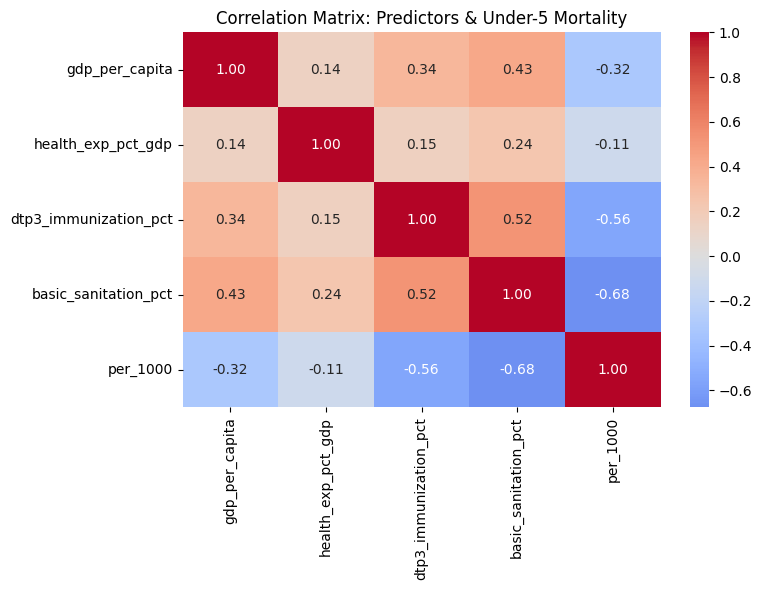

In [ ]:
#Correlation
predictors = ['gdp_per_capita', 'health_exp_pct_gdp', 'dtp3_immunization_pct', 'basic_sanitation_pct']
target = 'per_1000'

corr_matrix = mortality_socio_22_non_f[predictors + [target]].corr()
print(corr_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix: Predictors & Under-5 Mortality')
plt.tight_layout()
plt.savefig(f'{'/content/drive/MyDrive/Portfolio/30 Days Challenge/Day 9'}/correlation_heatmap.png', dpi=150)
plt.show()

In [ ]:
#VIF Calcualation
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = mortality_socio_22_non_f[predictors]
# VIF calculation requires an intercept term
X = add_constant(X)

vif_data = pd.DataFrame()
vif_data["variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data[vif_data["variable"] != "const"])

                variable       VIF
1         gdp_per_capita  1.253937
2     health_exp_pct_gdp  1.062487
3  dtp3_immunization_pct  1.408360
4   basic_sanitation_pct  1.567817
